In [1]:
# 데이터분석 :
# 구조화, 전처리, 정제, 타입
# A라는 데이터를 제공 -> 분석!!! (기술적 x)
# 데이터를 효율적으로 분석하기 위한 과정 학습 = EDA
# Exploarotory Data Analysis = 탐색적 데이터 분석 과정

# EDA by 존 튜키 미국의 통계학자
# 1) 데이터 출처 & 데이터가 담고 있는 주제 이해 = 도메인 이해
# 2) 데이터의 크기 확인 = 모집단 범위(규모) = 데이터 신뢰도
# 3) 데이터 안에 포함되어있는 각 구성 요소(feature = Series = field & column)를 파악하기 위한 목적
# feature engineering => 각 구성 요소들간의 상관관계를 분석하기 위한 목적으로 내부 값을 정제 혹은 전처리하는 일괄의 작업

# 실체하는 & 실존하는 리얼 데이터 => 학습 의미 (가짜, fake data)
# 대기업 > 데이터 구매 (카드사, 통신사)

In [2]:
import pandas as pd

doc = pd.read_csv("COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/04-01-2020.csv", encoding="utf-8-sig")

In [6]:
doc.head() # 해당 데이터 적재 순서에 맞춰서 5개만 출력

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"


In [9]:
doc.tail()

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.1307,-3.7837,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.5228,166.9315,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.0544,-169.8672,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.1095,177.6493,0,0,0,0,Tuvalu
2521,NaN,NaN,Pitcairn Islands,United Kingdom,2020-04-01 21:58:49,-24.3768,-128.3242,0,0,0,0,"Pitcairn Islands, United Kingdom"


In [ ]:
# 1) 데이터 출처 & 데이터가 담고 있는 주제 이해
# WHO기반으로 미국 + 주변 국가들의 코로나 감염확인, 사망, 회복, 진행중 데이터
# 2) 데이터 크기
# 2020-04-01, 2,522개 국가 및 도시의 코로나 관련 정보를 12개의 컬럼을 기준으로 관리
# 결측치가 얼만큼 존재 => 유효한 데이터로 판단할 수 있는 데이터 크기
# 3) 데이터 내부에 존재하는 각 feature 상관관계 분석
# 이러한 목적으로 이러이러한 데이터를 수집했나보다.
# 이 데이터와 이 데이터를 활용하면 향후 이러한 성격의 데이터를 확인해볼 수 있겠구나.
# 드릴모드 (국가 > 주 > 도시 > 우편번호)
# 특정 날짜의 마감시간
# 특정 지역의 정확한 위치 (위.경도)
# 확진.사망.회복.감염
# 향후 데이터 분석 시, 효율성 (주, 도시 CONCAT 기능활용 하나로 수집)
# 상관관계 파악.분석 > 2500여개

In [10]:
doc.shape

(2522, 12)

In [11]:
doc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2522 entries, 0 to 2521
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FIPS            2175 non-null   float64
 1   Admin2          2221 non-null   object 
 2   Province_State  2338 non-null   object 
 3   Country_Region  2522 non-null   object 
 4   Last_Update     2522 non-null   object 
 5   Lat             2518 non-null   float64
 6   Long_           2518 non-null   float64
 7   Confirmed       2522 non-null   int64  
 8   Deaths          2522 non-null   int64  
 9   Recovered       2522 non-null   int64  
 10  Active          2522 non-null   int64  
 11  Combined_Key    2522 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 236.6+ KB


In [12]:
doc.columns

Index(['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update',
       'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'Combined_Key'],
      dtype='object')

In [13]:
doc.corr(numeric_only=True)

,FIPS,Lat,Long_,Confirmed,Deaths,Recovered,Active
FIPS,1.000000,0.160717,0.171490,-0.000504,0.076467,NaN,0.002718
Lat,0.160717,1.000000,-0.476426,0.029389,0.026309,-0.002781,0.035631
Long_,0.171490,-0.476426,1.000000,0.141126,0.096924,0.141932,0.119737
Confirmed,-0.000504,0.029389,0.141126,1.000000,0.837153,0.727305,0.942484
Deaths,0.076467,0.026309,0.096924,0.837153,1.000000,0.546858,0.796549
Recovered,NaN,-0.002781,0.141932,0.727305,0.546858,1.000000,0.462484
Active,0.002718,0.035631,0.119737,0.942484,0.796549,0.462484,1.000000


1. 상관관계 : A와 B가 서로 상관성이 존재하는가?
2. 기준.지표 : 상관계수 -> -1 ~ 0 ~ 1 (1에 수렴 | -1에 수렴 => 매우상관성이 존재 / 0에 수렴 상관성이 없음)
3. 상관관계 & 상관계수 -> 모델 정립 -? 1890년대 활동, 피어슨(Karl Pearson) 영국 수학자 & 통계학자
4. 피어슨 상관계수
5. 상관계수 : 1에 수렴 => 양의 상관관계 / -1에 수렴 => 음의 상관관계

In [14]:
# 데이터 시각화
# 어떤 중요한 정보를 담고 있는 지표 혹은 데이터가 있다고해도, 해당 데이터가 시각적으로 보기 어렵다면 좋은 데이터의 자격 x
# 데이터 시각화해주는 여러 라이브러리 모듈 (plotly, matplotlib, seaborn)
# matplotlib : 파이썬 > 데이터 시각화 라이브러리 모듈, 가장 오래, 안정화 -> 문법이 난해, 어려움
# seaborn : matplotlib과 함께 사용하는 경우 많음. 색상 테마를 다채롭게 사용하고자 할 때 도움 (색상테마, 차트 종류 & 기능 x)
# matplotlib + seaborn
# plotly (비교적 나중에 등장한 라이브러리 모듈, 난이도 그렇게 높지 않음, 색상테마 및 기타 기능 다양)

In [17]:
import matplotlib.pyplot as plt
# matplotlib => 설계도면 측정, 그리기 위한 라이브러리 모듈 시작 => 데이터 & 정보 시각화 라이브러리 모듈
import seaborn as sns

In [16]:
%matplotlib inline

In [ ]:
plt.figure(figsize=(5, 5)) # 그래프 작성, 전체 사이즈를 5, 5인치 (heatmap)

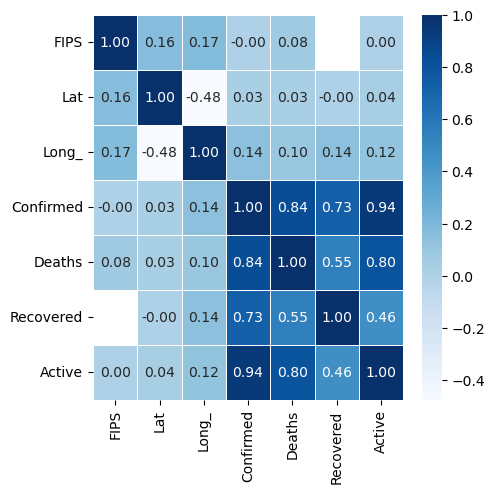

In [25]:
num_df = doc.select_dtypes(include="number")

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", linewidths=0.5, cmap="Blues", ax=ax)
plt.show()

In [26]:
import pandas as pd

doc = pd.read_csv("COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/04-01-2020.csv", encoding="utf-8-sig")
doc

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"
...,...,...,...,...,...,...,...,...,...,...,...,...
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.130700,-3.783700,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.522800,166.931500,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.109500,177.649300,0,0,0,0,Tuvalu


In [27]:
countries = doc["Country_Region"]
countries.head()

0    US
1    US
2    US
3    US
4    US
Name: Country_Region, dtype: object

In [34]:
print(countries.shape, countries.size, countries.count())
print(countries.unique())
print(countries.value_counts())

(2522,) 2522 2522
['US' 'Canada' 'United Kingdom' 'China' 'Netherlands' 'Australia'
 'Denmark' 'France' 'Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Austria' 'Azerbaijan'
 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burma' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Central African Republic' 'Chad' 'Chile'
 'Colombia' 'Congo (Brazzaville)' 'Congo (Kinshasa)' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Diamond Princess'
 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini'
 'Ethiopia' 'Fiji' 'Finland' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'Holy See' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran'
 'Iraq' 'Ire

In [36]:
covid_stat = doc[["Confirmed", "Deaths", "Recovered"]]
covid_stat.head()

,Confirmed,Deaths,Recovered
0,4,0,0
1,47,1,0
2,7,0,0
3,195,3,0
4,1,0,0


In [40]:
import pandas as pd

PATH = "COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/"
doc = pd.read_csv(f"{PATH}04-01-2020.csv", encoding="utf-8-sig")

In [41]:
doc

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"
...,...,...,...,...,...,...,...,...,...,...,...,...
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.130700,-3.783700,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.522800,166.931500,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.109500,177.649300,0,0,0,0,Tuvalu


In [43]:
doc_us = doc[doc["Country_Region"] == "US"]

In [45]:
doc_us.shape

(2228, 12)

In [46]:
doc_us.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2228 entries, 0 to 2303
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FIPS            2171 non-null   float64
 1   Admin2          2221 non-null   object 
 2   Province_State  2228 non-null   object 
 3   Country_Region  2228 non-null   object 
 4   Last_Update     2228 non-null   object 
 5   Lat             2227 non-null   float64
 6   Long_           2227 non-null   float64
 7   Confirmed       2228 non-null   int64  
 8   Deaths          2228 non-null   int64  
 9   Recovered       2228 non-null   int64  
 10  Active          2228 non-null   int64  
 11  Combined_Key    2228 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 226.3+ KB


In [47]:
doc_us.size

26736

In [48]:
doc_us.count()

FIPS              2171
Admin2            2221
Province_State    2228
Country_Region    2228
Last_Update       2228
Lat               2227
Long_             2227
Confirmed         2228
Deaths            2228
Recovered         2228
Active            2228
Combined_Key      2228
dtype: int64

In [ ]:
# 데이터를 분석하기 위해서 1) 데이터프레임 > 특정 시리즈(컬럼)만 추출하는 방법, 2) 데이터프레임 > 특정 조건에 해당되는 값만 추출하는 것

In [49]:
import pandas as pd

PATH = "COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/"
doc = pd.read_csv(f"{PATH}01-22-2020.csv", encoding="utf-8-sig")

doc

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,Anhui,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
1,Beijing,Mainland China,1/22/2020 17:00,14.0,NaN,NaN
2,Chongqing,Mainland China,1/22/2020 17:00,6.0,NaN,NaN
3,Fujian,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
4,Gansu,Mainland China,1/22/2020 17:00,NaN,NaN,NaN
...,...,...,...,...,...,...
71,Unknown,United Kingdom,1/22/2020 17:00,0.0,0.0,0.0
72,NaN,Nauru,1/22/2020 17:00,0.0,0.0,0.0
73,Niue,New Zealand,1/22/2020 17:00,0.0,0.0,0.0
74,NaN,Tuvalu,1/22/2020 17:00,0.0,0.0,0.0


In [50]:
doc.isnull()

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,False,False,False,False,True,True
1,False,False,False,False,True,True
2,False,False,False,False,True,True
3,False,False,False,False,True,True
4,False,False,False,True,True,True
...,...,...,...,...,...,...
71,False,False,False,False,False,False
72,True,False,False,False,False,False
73,False,False,False,False,False,False
74,True,False,False,False,False,False


In [51]:
doc.isnull().sum()

Province/State    12
Country/Region     0
Last Update        0
Confirmed         10
Deaths            37
Recovered         37
dtype: int64

In [ ]:
# null -> 연산처리 가능한 상태의 값으로 변환 (0, 최소), 삭제 및 제거

In [52]:
doc = doc.dropna()

In [56]:
doc.isnull().sum()

Province/State    12
Country/Region     0
Last Update        0
Confirmed         10
Deaths            37
Recovered         37
dtype: int64

In [ ]:
# drop => 데이터 갯수 (전체 데이터에 영향을 미칠정도 x -> 50% 기준)

In [57]:
import pandas as pd

PATH = "COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/"
doc = pd.read_csv(f"{PATH}01-22-2020.csv", encoding="utf-8-sig")

In [59]:
doc.isnull().sum()

Province/State    12
Country/Region     0
Last Update        0
Confirmed         10
Deaths            37
Recovered         37
dtype: int64

In [60]:
# na => not available

doc = doc.dropna(subset=["Confirmed"])

In [61]:
doc.isnull().sum()

Province/State    12
Country/Region     0
Last Update        0
Confirmed          0
Deaths            27
Recovered         27
dtype: int64

In [62]:
doc = doc.fillna(0)

In [63]:
doc.isnull().sum()

Province/State    0
Country/Region    0
Last Update       0
Confirmed         0
Deaths            0
Recovered         0
dtype: int64

In [64]:
import pandas as pd

PATH = "COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/"
doc = pd.read_csv(f"{PATH}01-22-2020.csv", encoding="utf-8-sig")

doc

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,Anhui,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
1,Beijing,Mainland China,1/22/2020 17:00,14.0,NaN,NaN
2,Chongqing,Mainland China,1/22/2020 17:00,6.0,NaN,NaN
3,Fujian,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
4,Gansu,Mainland China,1/22/2020 17:00,NaN,NaN,NaN
...,...,...,...,...,...,...
71,Unknown,United Kingdom,1/22/2020 17:00,0.0,0.0,0.0
72,NaN,Nauru,1/22/2020 17:00,0.0,0.0,0.0
73,Niue,New Zealand,1/22/2020 17:00,0.0,0.0,0.0
74,NaN,Tuvalu,1/22/2020 17:00,0.0,0.0,0.0


In [65]:
doc = doc.fillna({"Deaths": 0, "Recovered": 0})

In [66]:
doc.isnull().sum()

Province/State    12
Country/Region     0
Last Update        0
Confirmed         10
Deaths             0
Recovered          0
dtype: int64

In [67]:
import pandas as pd

PATH = "COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/"
doc = pd.read_csv(f"{PATH}04-01-2020.csv", encoding="utf-8-sig")

doc

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"
...,...,...,...,...,...,...,...,...,...,...,...,...
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.130700,-3.783700,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.522800,166.931500,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.109500,177.649300,0,0,0,0,Tuvalu


In [69]:
doc = doc.groupby(["Country_Region"]).sum()
doc.head()

,FIPS,Admin2,Province_State,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
Country_Region,,,,,,,,,,,
Afghanistan,0.0,0,0,2020-04-01 21:58:34,33.93911,67.709953,192,4,5,183,Afghanistan
Albania,0.0,0,0,2020-04-01 21:58:34,41.15330,20.168300,259,15,67,177,Albania
Algeria,0.0,0,0,2020-04-01 21:58:34,28.03390,1.659600,847,58,61,728,Algeria
Andorra,0.0,0,0,2020-04-01 21:58:34,42.50630,1.521800,390,14,10,366,Andorra
Angola,0.0,0,0,2020-04-01 21:58:34,-11.20270,17.873900,8,2,1,5,Angola


In [70]:
doc.columns

Index(['FIPS', 'Admin2', 'Province_State', 'Last_Update', 'Lat', 'Long_',
       'Confirmed', 'Deaths', 'Recovered', 'Active', 'Combined_Key'],
      dtype='object')

In [71]:
doc.index

Index(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antarctica',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       ...
       'United Arab Emirates', 'United Kingdom', 'Uruguay', 'Uzbekistan',
       'Venezuela', 'Vietnam', 'West Bank and Gaza', 'Winter Olympics 2022',
       'Zambia', 'Zimbabwe'],
      dtype='object', name='Country_Region', length=190)

In [72]:
doc[doc.index == "US"]

,FIPS,Admin2,Province_State,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
Country_Region,,,,,,,,,,,
US,65168934.0,AbbevilleAcadiaAccomackAdaAdairAdairAdairAdams...,South CarolinaLouisianaVirginiaIdahoIowaMissou...,2020-04-01 21:58:492020-04-01 21:58:492020-04-...,82956.96013,-197553.963757,216936,5222,8474,209150,"Abbeville, South Carolina, USAcadia, Louisiana..."


In [99]:
# 1. 전체 데이터의 사이즈, 결측지 정보 = size, shape, info, count
# 2. 결측치 발생치 대처방안 = fillna(), dropna()
# 3. 특정조건에 해당되는 값 찾기 = doc[doc.index == "US"]
# 4. 특정컬럼만 갖 찾아오기 = covid_stat = doc[["Confirmed", "Deaths", "Recovered"]]
# 5. 타입변경 시, 결측치부터 해결 = doc2 = doc2.astype({"Confirmed": "int64"})
# 6. 서로다른 데이터 연결 시, 동일한 필드명 통일 = doc3.columns = ['Country_Region', 'Confirmed']
# 7. 중복값 존재 시, 삭제.제거 = doc4 = doc4.drop_duplicates(subset="Country_Region")

In [73]:
import pandas as pd
PATH = "COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/"
doc = pd.read_csv(f"{PATH}01-22-2020.csv", encoding="utf-8-sig")

doc

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,Anhui,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
1,Beijing,Mainland China,1/22/2020 17:00,14.0,NaN,NaN
2,Chongqing,Mainland China,1/22/2020 17:00,6.0,NaN,NaN
3,Fujian,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
4,Gansu,Mainland China,1/22/2020 17:00,NaN,NaN,NaN
...,...,...,...,...,...,...
71,Unknown,United Kingdom,1/22/2020 17:00,0.0,0.0,0.0
72,NaN,Nauru,1/22/2020 17:00,0.0,0.0,0.0
73,Niue,New Zealand,1/22/2020 17:00,0.0,0.0,0.0
74,NaN,Tuvalu,1/22/2020 17:00,0.0,0.0,0.0


In [74]:
doc2 = doc[["Country/Region", "Confirmed"]]
doc2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country/Region  76 non-null     object 
 1   Confirmed       66 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB


In [75]:
doc2.isnull().sum()

Country/Region     0
Confirmed         10
dtype: int64

In [76]:
doc2 = doc2.dropna(subset=["Confirmed"])

In [77]:
doc2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 0 to 75
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country/Region  66 non-null     object 
 1   Confirmed       66 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.5+ KB


In [78]:
doc2.isnull().sum()

Country/Region    0
Confirmed         0
dtype: int64

In [79]:
doc2 = doc2.astype({"Confirmed": "int64"})

In [80]:
doc2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 0 to 75
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country/Region  66 non-null     object
 1   Confirmed       66 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ KB


In [82]:
import pandas as pd
PATH = "COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/"
doc = pd.read_csv(f"{PATH}01-22-2020.csv", encoding="utf-8-sig")

doc

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,Anhui,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
1,Beijing,Mainland China,1/22/2020 17:00,14.0,NaN,NaN
2,Chongqing,Mainland China,1/22/2020 17:00,6.0,NaN,NaN
3,Fujian,Mainland China,1/22/2020 17:00,1.0,NaN,NaN
4,Gansu,Mainland China,1/22/2020 17:00,NaN,NaN,NaN
...,...,...,...,...,...,...
71,Unknown,United Kingdom,1/22/2020 17:00,0.0,0.0,0.0
72,NaN,Nauru,1/22/2020 17:00,0.0,0.0,0.0
73,Niue,New Zealand,1/22/2020 17:00,0.0,0.0,0.0
74,NaN,Tuvalu,1/22/2020 17:00,0.0,0.0,0.0


In [83]:
doc.columns

Index(['Province/State', 'Country/Region', 'Last Update', 'Confirmed',
       'Deaths', 'Recovered'],
      dtype='object')

In [84]:
doc3 = doc[['Country/Region', 'Confirmed']]
doc3

,Country/Region,Confirmed
0,Mainland China,1.0
1,Mainland China,14.0
2,Mainland China,6.0
3,Mainland China,1.0
4,Mainland China,NaN
...,...,...
71,United Kingdom,0.0
72,Nauru,0.0
73,New Zealand,0.0
74,Tuvalu,0.0


In [85]:
doc3.columns = ['Country_Region', 'Confirmed']

In [86]:
doc3

,Country_Region,Confirmed
0,Mainland China,1.0
1,Mainland China,14.0
2,Mainland China,6.0
3,Mainland China,1.0
4,Mainland China,NaN
...,...,...
71,United Kingdom,0.0
72,Nauru,0.0
73,New Zealand,0.0
74,Tuvalu,0.0


In [88]:
PATH = "COVID-19-master/csse_covid_19_data/"

doc = pd.read_csv(f"{PATH}UID_ISO_FIPS_LookUp_Table.csv", encoding="utf-8-sig")
doc4 = doc[["iso2", "Country_Region"]]

doc4

,iso2,Country_Region
0,AF,Afghanistan
1,AL,Albania
2,AQ,Antarctica
3,DZ,Algeria
4,AD,Andorra
...,...,...
4316,US,US
4317,US,US
4318,US,US
4319,US,US


In [89]:
doc4.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4316     True
4317     True
4318     True
4319     True
4320     True
Length: 4321, dtype: bool

In [91]:
doc4[doc4.duplicated()]

,iso2,Country_Region
17,BE,Belgium
18,BE,Belgium
19,BE,Belgium
20,BE,Belgium
21,BE,Belgium
...,...,...
4316,US,US
4317,US,US
4318,US,US
4319,US,US


In [95]:
doc4 = doc4.drop_duplicates(subset="Country_Region")

In [97]:
doc4.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
853    False
854    False
863    False
880    False
915    False
Length: 202, dtype: bool

In [98]:
doc4

,iso2,Country_Region
0,AF,Afghanistan
1,AL,Albania
2,AQ,Antarctica
3,DZ,Algeria
4,AD,Andorra
...,...,...
853,ZW,Zimbabwe
854,AU,Australia
863,CA,Canada
880,CN,China
